# SQL analysis: where the time goes and what runs late

Reads the tables built by `sql/05_analysis.sql` in `data/processed/radar.duckdb` (run `python -m etl.run_pipeline` first). Scope: 8 Apache projects, delivered tickets only unless a chart says otherwise. "Late" follows `GLOSSARY.md`. Charts name their takeaway; every chart is followed by its table.

Two cautions that shape the reading:

- **Four projects review on GitHub, not in Jira statuses**, so their time in "In review" is 0% by construction. Compare stage shares within a workflow family, not across.
- **Late rates for recent tickets are biased if you count only delivered tickets** (chart 2). The label used for modelling counts open tickets that are already past their threshold.

In [1]:
import duckdb, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

con = duckdb.connect("../data/processed/radar.duckdb", read_only=True)
q = lambda sql: con.execute(sql).df()

# Validated categorical slots 1-3 (light) from the dataviz reference palette; text and grid wear neutral ink.
BLUE, ORANGE, AQUA, GAP = "#2a78d6", "#eb6834", "#1baf7a", "#c9c8c2"
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID, "axes.grid": False})

def tidy(ax, grid="y"):
    ax.grid(axis=grid, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(length=0)

## 1. Where the time goes
Share of total lead time spent in each stage. In the projects that use Jira review statuses, tickets mostly wait; the active In Progress stage is a few percent.

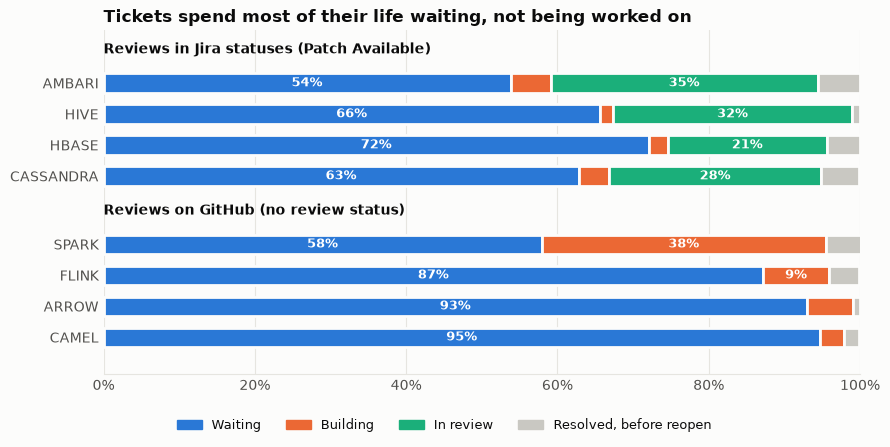

,tickets,waiting_pct,building_pct,in_review_pct,resolved_gap_pct
project_key,,,,,
HBASE,13609,72.1,2.5,21.0,4.4
CAMEL,11317,94.7,3.2,0.0,2.0
SPARK,17475,57.9,37.6,0.0,4.6
CASSANDRA,9302,62.8,4.0,28.1,5.0
ARROW,9996,93.0,6.1,0.0,0.9
AMBARI,15885,53.8,5.3,35.3,5.6
FLINK,11234,87.2,8.7,0.0,4.0
HIVE,12300,65.6,1.7,31.7,1.0


In [2]:
share = q("select * from analysis_stage_share").set_index("project_key")
groups = [("Reviews in Jira statuses (Patch Available)", ["AMBARI", "HIVE", "HBASE", "CASSANDRA"]),
          ("Reviews on GitHub (no review status)", ["SPARK", "FLINK", "ARROW", "CAMEL"])]
parts = [("waiting_pct", "Waiting", BLUE), ("building_pct", "Building", ORANGE), ("in_review_pct", "In review", AQUA), ("resolved_gap_pct", "Resolved, before reopen", GAP)]

fig, ax = plt.subplots(figsize=(9, 4.6)); y, ticks, labels = 0, [], []
for title, projects in groups:
    ax.text(0, y - 0.15, title, fontsize=10, fontweight="bold", color=INK, va="bottom"); y += 0.7
    for p in projects:
        left = 0
        for col, name, color in parts:
            w = share.loc[p, col]
            ax.barh(y, w, left=left, color=color, edgecolor=SURFACE, linewidth=2, height=0.62)
            if w >= 7: ax.text(left + w / 2, y, f"{w:.0f}%", ha="center", va="center", color="white" if color != GAP else INK, fontsize=9, fontweight="bold")
            left += w
        ticks.append(y); labels.append(p); y += 1
    y += 0.5
ax.set_yticks(ticks, labels); ax.set_ylim(y - 0.3, -1.0); ax.set_xlim(0, 100); ax.xaxis.set_major_formatter(PercentFormatter())
tidy(ax, "x"); ax.spines["left"].set_visible(False)
ax.set_title("Tickets spend most of their life waiting, not being worked on", loc="left", fontsize=12, fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for _, _, c in parts]
ax.legend(handles, [n for _, n, _ in parts], ncol=4, frameon=False, loc="lower center", bbox_to_anchor=(0.45, -0.2), fontsize=9)
plt.tight_layout(); plt.show()
share.round(1)

## 2. Counting only delivered tickets understates lateness for recent cohorts
Among delivered tickets, the late rate falls for tickets created in 2020 and 2021. That is censoring: the slow ones are not delivered yet, so only the fast ones are in the data. Counting open tickets that are already past their threshold as late removes the bias, and the rate stays high.

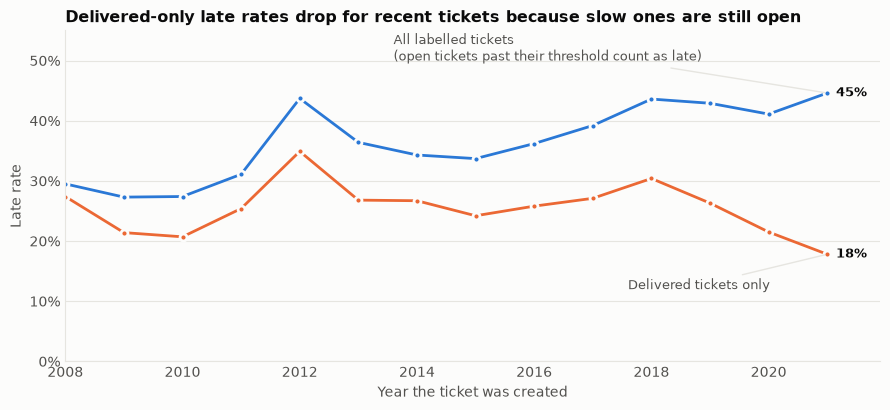

,all_labelled,delivered_only,tickets
year,,,
2008,29.5,27.4,1292
2009,27.3,21.4,2414
2010,27.4,20.7,2938
2011,31.1,25.4,3753
2012,43.7,34.9,4356
2013,36.4,26.8,7108
2014,34.3,26.7,11168
2015,33.7,24.2,14756
2016,36.2,25.8,14174


In [3]:
trend = q('''select year(created) as year,
   round(100*avg(is_late::int), 1) as all_labelled,
   round(100*avg(is_late_delivered_only::int), 1) as delivered_only,
   count(*) as tickets
 from labels where label_status in ('labelled','open_known_late') and year(created) between 2008 and 2021 group by 1 order by 1''').set_index("year")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(trend.index, trend["all_labelled"], color=BLUE, linewidth=2, marker="o", markersize=5, markeredgecolor=SURFACE, markeredgewidth=2)
ax.plot(trend.index, trend["delivered_only"], color=ORANGE, linewidth=2, marker="o", markersize=5, markeredgecolor=SURFACE, markeredgewidth=2)
ax.annotate("All labelled tickets\n(open tickets past their threshold count as late)", (2021, trend.loc[2021, "all_labelled"]), xytext=(2013.6, 50), color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=GRID))
ax.annotate("Delivered tickets only", (2021, trend.loc[2021, "delivered_only"]), xytext=(2017.6, 12), color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=GRID))
ax.text(2021.15, trend.loc[2021, "all_labelled"], f"{trend.loc[2021, 'all_labelled']:.0f}%", color=INK, va="center", fontsize=9, fontweight="bold")
ax.text(2021.15, trend.loc[2021, "delivered_only"], f"{trend.loc[2021, 'delivered_only']:.0f}%", color=INK, va="center", fontsize=9, fontweight="bold")
ax.set_xlim(2008, 2021.9); ax.set_ylim(0, 55); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_xticks(range(2008, 2022, 2))
tidy(ax); ax.set_ylabel("Late rate"); ax.set_xlabel("Year the ticket was created")
ax.set_title("Delivered-only late rates drop for recent tickets because slow ones are still open", loc="left", fontsize=11.5, fontweight="bold")
plt.tight_layout(); plt.show()
trend

## 3. Waiting for a first review
In the four projects that review through Jira statuses. Median waits are short, but the slow quarter is where the delay lives; CASSANDRA's P75 wait is about two weeks.

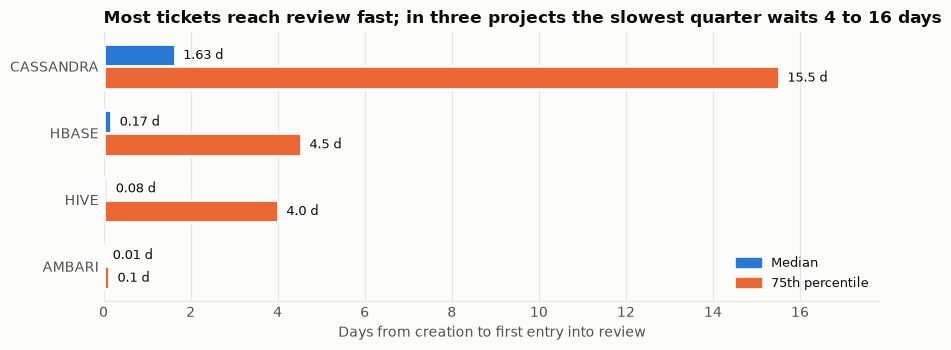

,entered_review_pct,median,p75,any_rework_pct
project_key,,,,
CASSANDRA,83.0,1.63,15.51,8.4
HBASE,67.6,0.17,4.53,12.6
HIVE,83.3,0.08,4.00,21.4
AMBARI,73.6,0.01,0.12,6.0


In [4]:
wait = q("select project_key, entered_review_pct, median_wait_to_review_days as median, p75_wait_to_review_days as p75, any_rework_pct from analysis_review_flow where entered_review_pct > 0 order by p75 desc").set_index("project_key")
fig, ax = plt.subplots(figsize=(9, 3.6)); h = 0.34
for i, p in enumerate(wait.index):
    ax.barh(i - h / 2, wait.loc[p, "median"], height=h, color=BLUE, edgecolor=SURFACE, linewidth=2)
    ax.barh(i + h / 2, wait.loc[p, "p75"], height=h, color=ORANGE, edgecolor=SURFACE, linewidth=2)
    ax.text(wait.loc[p, "median"] + 0.2, i - h / 2, f"{wait.loc[p, 'median']:.2f} d", va="center", fontsize=9, color=INK)
    ax.text(wait.loc[p, "p75"] + 0.2, i + h / 2, f"{wait.loc[p, 'p75']:.1f} d", va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(wait)), wait.index); ax.invert_yaxis(); ax.set_xlim(0, wait["p75"].max() * 1.15)
tidy(ax, "x"); ax.spines["left"].set_visible(False); ax.set_xlabel("Days from creation to first entry into review")
ax.set_title("Most tickets reach review fast; in three projects the slowest quarter waits 4 to 16 days", loc="left", fontsize=12, fontweight="bold")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)], ["Median", "75th percentile"], frameon=False, loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()
wait

## 4. What the late rate does and does not track
Left: priority barely separates late from on-time (Blockers are *less* often late). Right: tickets with more links are more often late, but link counts here are the end-of-life count, which grows as a ticket lives. They are not creation-time facts and must not become features without rebuilding them as of the prediction point.

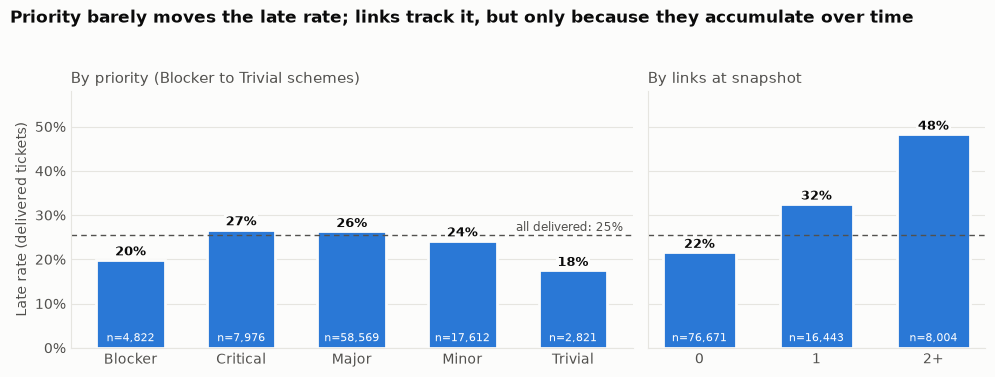

n  late_pct
priority          Blocker    4822      19.9
                  Critical   7976      26.7
                  Major     58569      26.3
                  Minor     17612      24.2
                  Trivial    2821      17.5
links at snapshot 0         76671      21.6
                  1         16443      32.5
                  2+         8004      48.3

In [5]:
pri = q('''select priority, count(*) n, round(100*avg(is_late::int),1) late_pct from analysis_base
  where priority in ('Blocker','Critical','Major','Minor','Trivial') group by 1''').set_index("priority").loc[["Blocker", "Critical", "Major", "Minor", "Trivial"]]
link = q("select level, tickets as n, late_pct from analysis_late_by_factor where factor = 'link_count_at_snapshot' order by level").set_index("level")
base = q("select round(100*avg(is_late::int),1) v from analysis_base")["v"][0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [5, 3]}, sharey=True)
for ax, d, title in ((a1, pri, "By priority (Blocker to Trivial schemes)"), (a2, link, "By links at snapshot")):
    bars = ax.bar(d.index, d["late_pct"], color=BLUE, edgecolor=SURFACE, linewidth=2, width=0.62)
    for b, (idx, r) in zip(bars, d.iterrows()):
        ax.text(b.get_x() + b.get_width() / 2, r["late_pct"] + 1, f"{r['late_pct']:.0f}%", ha="center", fontsize=9, fontweight="bold", color=INK, bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.2))
        ax.text(b.get_x() + b.get_width() / 2, 1.5, f"n={int(r['n']):,}", ha="center", fontsize=8, color="white")
    ax.axhline(base, color=INK2, linewidth=1, linestyle=(0, (4, 3))); tidy(ax); ax.set_title(title, loc="left", fontsize=10.5, color=INK2)
a1.text(4.45, base + 1, f"all delivered: {base:.0f}%", ha="right", fontsize=8.5, color=INK2)
a1.set_ylim(0, 58); a1.yaxis.set_major_formatter(PercentFormatter()); a1.set_ylabel("Late rate (delivered tickets)")
fig.suptitle("Priority barely moves the late rate; links track it, but only because they accumulate over time", x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()
pd.concat({"priority": pri, "links at snapshot": link})

## What this means for the model

- **Stage and review behaviour is workflow-specific.** Cross-project models should carry the workflow family (Jira review statuses or GitHub review) as a feature, and stage-based features only exist for the first family.
- **Priority is a weak signal**, so priority-only baselines will do little. The peer-group history and workload features carry more of the load.
- **End-of-life attributes (links, current assignee, components) look predictive but are leaks** unless rebuilt as of the prediction point. The leakage guard in the tests exists for exactly this.
- **Keep open, over-threshold tickets in the label** (`labels.is_late`), and do not evaluate on delivered-only rates for recent cohorts.